In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from robusta_hmf import Robusta
import time
#%matplotlib widget

In [29]:
#define constants
c = 299792.458 # km/s
LN10 = np.log(10.)
MAX_IVAR = 2.5e3
MIN_IVAR = 0.1
H_ALPHA, H_BETA = 6564.614, 4862.721 #Reference: from classic.sdss.org
HE_I_6680 = 6680 #Reference: Johanna brain
HE_I_4026 = 4026
HE_I_4471 = 4471
HE_I_4922 = 4922
HE_I_4713 = 4713
HE_II_4686 = 4686 #Reference: Johanna brain
HE_II_4542 = 4542
HE_II_4200 = 4200


#lines
lines_balmer = [H_ALPHA, H_BETA]
lines_HE_I = [HE_I_6680, HE_I_4026, HE_I_4471, HE_I_4922, HE_I_4713]
lines_HE_II = [HE_II_4686, HE_II_4542, HE_II_4200]
all_lines = np.concatenate([lines_balmer, lines_HE_I, lines_HE_II])
mask_lines = lines_balmer

#line labes
line_labels_balmer = ["Halpha", "Hbeta"] # JMH: add Hgamm, H delta also
line_labels_HE_I = ["HeI_6680", "HeI_4026", "HeI_4471", "HeI_4922", "HeI_4713"]
line_labels_HE_II = ["HeII_4686", "HeII_4542", "HeII_4200"]
all_line_labels = np.concatenate([line_labels_balmer, line_labels_HE_I, line_labels_HE_II])

statistics = ["EW", "shift", "width"]
moment_names = ["EW", "M1", "M2", "M3", "M4"]


H_delta_lnlam_line = 1000 / c 
H_delta_loglam_line = H_delta_lnlam_line / LN10 
HE_delta_lnlam_line = 500 / c
HE_delta_loglam_line = HE_delta_lnlam_line / LN10
# log_H_ALPHA, log_H_BETA, log_HE_I, log_HE_II = np.log10(H_ALPHA), np.log10(H_BETA), np.log10(HE_I), np.log10(HE_II)

#delta loglam line for labeling
delta_balmer = np.zeros(len(lines_balmer)) + (1000 / c) / LN10 
delta_HE_I = np.zeros(len(lines_HE_I)) + (500 / c) / LN10 
delta_HE_II = np.zeros(len(lines_HE_II)) + (500 / c) / LN10 
all_delta_loglams = np.concatenate([delta_balmer, delta_HE_I, delta_HE_II])


#indexing is super important for these three arrays 
print(all_lines.shape, all_line_labels.shape, all_delta_loglams.shape)
print(all_lines, all_line_labels, all_delta_loglams)

H_delta_lnlam_line = 1000 / c 
H_delta_loglam_line = H_delta_lnlam_line / LN10 
HE_delta_lnlam_line = 500 / c
HE_delta_loglam_line = HE_delta_lnlam_line / LN10
log_H_ALPHA, log_H_BETA = np.log10(H_ALPHA), np.log10(H_BETA)


half_wids = [H_delta_loglam_line, H_delta_loglam_line, HE_delta_loglam_line, HE_delta_loglam_line, HE_delta_loglam_line, HE_delta_loglam_line,
            HE_delta_loglam_line, HE_delta_loglam_line, HE_delta_loglam_line, HE_delta_loglam_line] 

assert len(half_wids) == len(all_lines)

#THIS MUST BE ASCENDING ORDER
temp_cuts = np.array([10000, 15000, 25000, np.inf])
mod_list = [0,1]


(10,) (10,) (10,)
[6564.614 4862.721 6680.    4026.    4471.    4922.    4713.    4686.
 4542.    4200.   ] ['Halpha' 'Hbeta' 'HeI_6680' 'HeI_4026' 'HeI_4471' 'HeI_4922' 'HeI_4713'
 'HeII_4686' 'HeII_4542' 'HeII_4200'] [0.00144865 0.00144865 0.00072433 0.00072433 0.00072433 0.00072433
 0.00072433 0.00072433 0.00072433 0.00072433]
10


In [3]:
print(all_lines)

[6564.614 4862.721 6680.    4026.    4471.    4922.    4713.    4686.
 4542.    4200.   ]


In [4]:
#load stellar parameters
DATESTR = "2026-07-20"

stars = pd.read_parquet(f"parent_stars10k_{DATESTR}.parquet")
print("num of stars in parquet:", stars.shape[0])

spectra_temp = pd.read_parquet(f"spectra_{DATESTR}_table.parquet")
print("num of spectra in parquet:", stars.shape[0])

print(stars.shape)


num of stars in parquet: 114190
num of spectra in parquet: 114190
(114190, 394)


In [290]:
print("spectra before:", spectra_temp.shape)
spectra = spectra_temp.join(stars[["GAIA_ID", "Teff_fit", "NANA_HASH", "logg_fit", "logL_fit"]].set_index("GAIA_ID"), on = "GAIA_ID", rsuffix = "_stars", how = "left", validate = "m:1")
print("spectra after:", spectra.shape)

spectra before: (24713, 846)
spectra after: (24713, 850)


In [6]:
nana = "nana_"
count = 0
for l, line in enumerate(all_line_labels):
    col_name = nana + line + "_"
    print(col_name)
    for s, stat in enumerate(moment_names):
        ##add column here
            #print(col_name + stat)
            spectra[col_name + stat] = 0.
            count+=1
            spectra[col_name + stat + "_err"] = np.inf
            count+=1


print(spectra.columns.to_list())


nana_Halpha_
nana_Hbeta_
nana_HeI_6680_
nana_HeI_4026_
nana_HeI_4471_
nana_HeI_4922_
nana_HeI_4713_
nana_HeII_4686_
nana_HeII_4542_
nana_HeII_4200_
['FIELD', 'MJD', 'OBS', 'MJD_FINAL', 'MJD_LIST', 'TAI_LIST', 'RUN2D', 'RUN1D', 'DESIGNS', 'CONFIGS', 'NEXP', 'EXPTIME', 'TARGET_INDEX', 'FIBERID_LIST', 'SPEC_FILE', 'PROGRAMNAME', 'SURVEY', 'CADENCE', 'FIRSTCARTON', 'CARTON_TO_TARGET_PK', 'OBJTYPE', 'TOO', 'TOO_ID', 'CATALOGID', 'CATALOGID_V0', 'CATALOGID_V0P5', 'CATALOGID_V1', 'SDSS_ID', 'SPECOBJID', 'OPTICAL_PROV', 'GAIA_G_MAG', 'GRI_GAIA_TRANSFORM', 'BP_MAG', 'RP_MAG', 'GAIA_ID', 'WISE_MAG_1', 'WISE_MAG_2', 'WISE_MAG_3', 'WISE_MAG_4', 'TWOMASS_MAG_1', 'TWOMASS_MAG_2', 'TWOMASS_MAG_3', 'GUVCAT_MAG_1', 'GUVCAT_MAG_2', 'EBV', 'EBV_TYPE', 'FIBER_RA', 'FIBER_DEC', 'PLUG_RA', 'PLUG_DEC', 'RACAT', 'DECCAT', 'COORD_EPOCH', 'PMRA', 'PMDEC', 'PARALLAX', 'RA_LIST', 'DEC_LIST', 'DELTA_RA_LIST', 'DELTA_DEC_LIST', 'FIBER_OFFSET', 'XFOCAL', 'YFOCAL', 'ZOFFSET', 'LAMBDA_EFF', 'BLUEFIBER', 'HEALPIX', 'HE

/var/folders/_f/c3__1v4j349bfc51yh6jhk_w0000gp/T/ipykernel_984/339012662.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  spectra[col_name + stat] = 0.
/var/folders/_f/c3__1v4j349bfc51yh6jhk_w0000gp/T/ipykernel_984/339012662.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  spectra[col_name + stat + "_err"] = np.inf
/var/folders/_f/c3__1v4j349bfc51yh6jhk_w0000gp/T/ipykernel_984/339012662.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

In [291]:
nana = "nana_"
count = 0
for l, line in enumerate(all_line_labels):
    col_name = nana + line + "_"
    print(col_name)
    for s, stat in enumerate(moment_names):
        ##add column here
            #print(col_name + stat)
            spectra[col_name + stat + "_synth"] = 0.
            count+=1
            spectra[col_name + stat + "_synth_err"] = np.inf
            count+=1


print(spectra.columns.to_list())


nana_Halpha_
nana_Hbeta_
nana_HeI_6680_
nana_HeI_4026_
nana_HeI_4471_
nana_HeI_4922_
nana_HeI_4713_
nana_HeII_4686_
nana_HeII_4542_
nana_HeII_4200_
['FIELD', 'MJD', 'OBS', 'MJD_FINAL', 'MJD_LIST', 'TAI_LIST', 'RUN2D', 'RUN1D', 'DESIGNS', 'CONFIGS', 'NEXP', 'EXPTIME', 'TARGET_INDEX', 'FIBERID_LIST', 'SPEC_FILE', 'PROGRAMNAME', 'SURVEY', 'CADENCE', 'FIRSTCARTON', 'CARTON_TO_TARGET_PK', 'OBJTYPE', 'TOO', 'TOO_ID', 'CATALOGID', 'CATALOGID_V0', 'CATALOGID_V0P5', 'CATALOGID_V1', 'SDSS_ID', 'SPECOBJID', 'OPTICAL_PROV', 'GAIA_G_MAG', 'GRI_GAIA_TRANSFORM', 'BP_MAG', 'RP_MAG', 'GAIA_ID', 'WISE_MAG_1', 'WISE_MAG_2', 'WISE_MAG_3', 'WISE_MAG_4', 'TWOMASS_MAG_1', 'TWOMASS_MAG_2', 'TWOMASS_MAG_3', 'GUVCAT_MAG_1', 'GUVCAT_MAG_2', 'EBV', 'EBV_TYPE', 'FIBER_RA', 'FIBER_DEC', 'PLUG_RA', 'PLUG_DEC', 'RACAT', 'DECCAT', 'COORD_EPOCH', 'PMRA', 'PMDEC', 'PARALLAX', 'RA_LIST', 'DEC_LIST', 'DELTA_RA_LIST', 'DELTA_DEC_LIST', 'FIBER_OFFSET', 'XFOCAL', 'YFOCAL', 'ZOFFSET', 'LAMBDA_EFF', 'BLUEFIBER', 'HEALPIX', 'HE

/var/folders/_f/c3__1v4j349bfc51yh6jhk_w0000gp/T/ipykernel_984/1594213659.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  spectra[col_name + stat + "_synth"] = 0.
/var/folders/_f/c3__1v4j349bfc51yh6jhk_w0000gp/T/ipykernel_984/1594213659.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  spectra[col_name + stat + "_synth_err"] = np.inf
/var/folders/_f/c3__1v4j349bfc51yh6jhk_w0000gp/T/ipykernel_984/1594213659.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many 

In [7]:
# sanity check contents of file
print(spectra[["GAIA_ID", "NANA_HASH", "Teff_fit", "EWobs_Halpha", "rv_hydrogen_all_mean", "SPEC_FILE"]])

                    GAIA_ID  NANA_HASH      Teff_fit  EWobs_Halpha  \
24      3044828455036183168       3063  12761.479713      6.551737   
44      4252966501578008448        515  15365.889060      4.354832   
194     4313037460368726144       1407  12978.622277      5.968537   
239     4265315498999514240       3320  12707.346474      6.222246   
282     4266381819051350272       2267  13057.268868      6.164106   
...                     ...        ...           ...           ...   
706759  5328523619275128448        637  20033.774333      4.023864   
706787  5526077859899761664       2624  15000.114492      5.219253   
706796  5526214852177608832       1672  11620.259271      7.460024   
706806  5527055600616580480       3416  15018.876756      4.534016   
706808  5356323190234251520       1330  11163.021941      8.260585   

        rv_hydrogen_all_mean                                 SPEC_FILE  
24                 97.976125  spec-019583-59629-27021598031539611.fits  
44           

In [8]:
#read in the data and deal with radial velocities

#take the ALL spectra (like 35,000)
with open(f'spectra_{DATESTR}_data.pkl','rb') as f:
    pkl_data = pickle.load(f)
print(len(pkl_data))

9


In [9]:
#pkl of ALL spectra (Teff > 10000)
# BUG: This code is very brittle
fluxes, loglam, ivars, continuua, _, _, _, _, _ = pkl_data
print(fluxes.shape, loglam.shape, ivars.shape, continuua.shape)

(24713, 4648) (4648,) (24713, 4648) (24713, 4648)


In [10]:
# hard stop if we SUCK
assert len(fluxes) == len(spectra)

In [11]:
# shift to rest frame.
# Note: Only does integer-pixel shifts
# Note: Data have been slightly corrupted; delta_log_lam is not consistent across the wavelength grid.

def get_delta_log_lam(loglambdas):
    return np.median(loglambdas[1:] - loglambdas[:-1])
    
def pixel_shift(flxs, ivrs, contins, rvs, log_lambda):

    delta_log_lambda_pixel = get_delta_log_lam(log_lambda)

    # Catch bad rv values, goddammit
    bad = np.logical_not(np.isfinite(rvs))
    rad_vels = rvs.copy()
    rad_vels[bad] = 0.

    delta_log_lambdas = (rad_vels / c) / LN10
    delta_pixels = np.round(delta_log_lambdas/delta_log_lambda_pixel).astype(int)

    rest_flxs = np.zeros_like(flxs) + 1.
    rest_ivrs = np.zeros_like(ivrs)
    rest_contins = np.zeros_like(contins) + np.nan

    for i, dp in enumerate(delta_pixels):
        if dp < 0:
            rest_flxs[i, -dp:] = flxs[i, :dp]
            rest_ivrs[i, -dp:] = ivrs[i, :dp]
            rest_contins[i, -dp:] = contins[i, :dp]
            
        elif dp > 0:
            rest_flxs[i, :-dp] = flxs[i, dp:]
            rest_ivrs[i, :-dp] = ivrs[i, dp:]
            rest_contins[i, :-dp] = contins[i, dp:]
            
        else:
            rest_flxs[i, :] = flxs[i, :]
            rest_ivrs[i, :] = ivrs[i, :]
            rest_contins[i, :] = contins[i, :]

    # dammit
    rest_ivrs[bad, :] = 0.
    print("zeroing out ivars on", np.sum(bad), "stars with bad rvs")
    return rest_flxs, rest_ivrs, rest_contins

In [12]:
# shift everything to the rest frame
rest_fluxes, rest_ivars, rest_continuua = pixel_shift(fluxes, ivars, continuua, spectra["rv_hydrogen_all_mean"].to_numpy(), loglam)
print(rest_fluxes.shape)

zeroing out ivars on 351 stars with bad rvs
(24713, 4648)


In [13]:
def fix_nans_and_infinites(rest_flxs, rest_ivrs):

    #fix nans and infinities
    bad = np.logical_not(np.isfinite(rest_flxs))
    rest_flxs[bad] = 1
    rest_ivrs[bad] = 0
    
    bad = np.logical_not(np.isfinite(rest_ivrs))
    rest_flxs[bad] = 1
    rest_ivrs[bad] = 0
    
    bad = np.logical_or((rest_flxs > 2.0), (rest_flxs < 0))
    rest_flxs[bad] = 1
    rest_ivrs[bad] = 0
    
    bad = rest_ivrs > MAX_IVAR
    # rest_fluxes[bad] = 1
    # rest_ivars[bad] = 0
    rest_ivrs[bad] = MAX_IVAR
    
    bad = rest_ivrs < MIN_IVAR
    rest_flxs[bad] = 1.0
    rest_ivrs[bad] = MIN_IVAR

    return rest_flxs, rest_ivrs

In [14]:
data, weights = fix_nans_and_infinites(rest_fluxes, rest_ivars)
print(data.shape, weights.shape, rest_continuua.shape)

(24713, 4648) (24713, 4648) (24713, 4648)


0 10000.00000000001 13696 10000.0
1 11023.104765790147 20764 11023.679343987918
2 12150.883867758515 11993 12151.6784909076
3 13394.04658712514 22839 13394.17958049255
4 14764.397876775427 15653 14764.089910014782
5 16274.9504599505 18322 16272.624400393652
6 17940.048397807845 10389 17944.14397135685
7 19775.50329923814 14787 19781.862080737672
8 21798.744466373053 11568 21802.971557655124
9 24028.98440155182 2512 24049.3217104071
10 26487.40124738423 20369 26562.211972423305
11 29197.339892343676 15793 29260.07789150486
12 32184.53365156881 6397 32169.93647889888
13 35477.34862793412 14719 35887.06576470069
14 39107.05307381782 12345 38950.47128094957
15 43108.1143114009 12754 39466.9904606415


Text(0.5, 1.0, 'selected high SNR example stars, ordered by Teff')

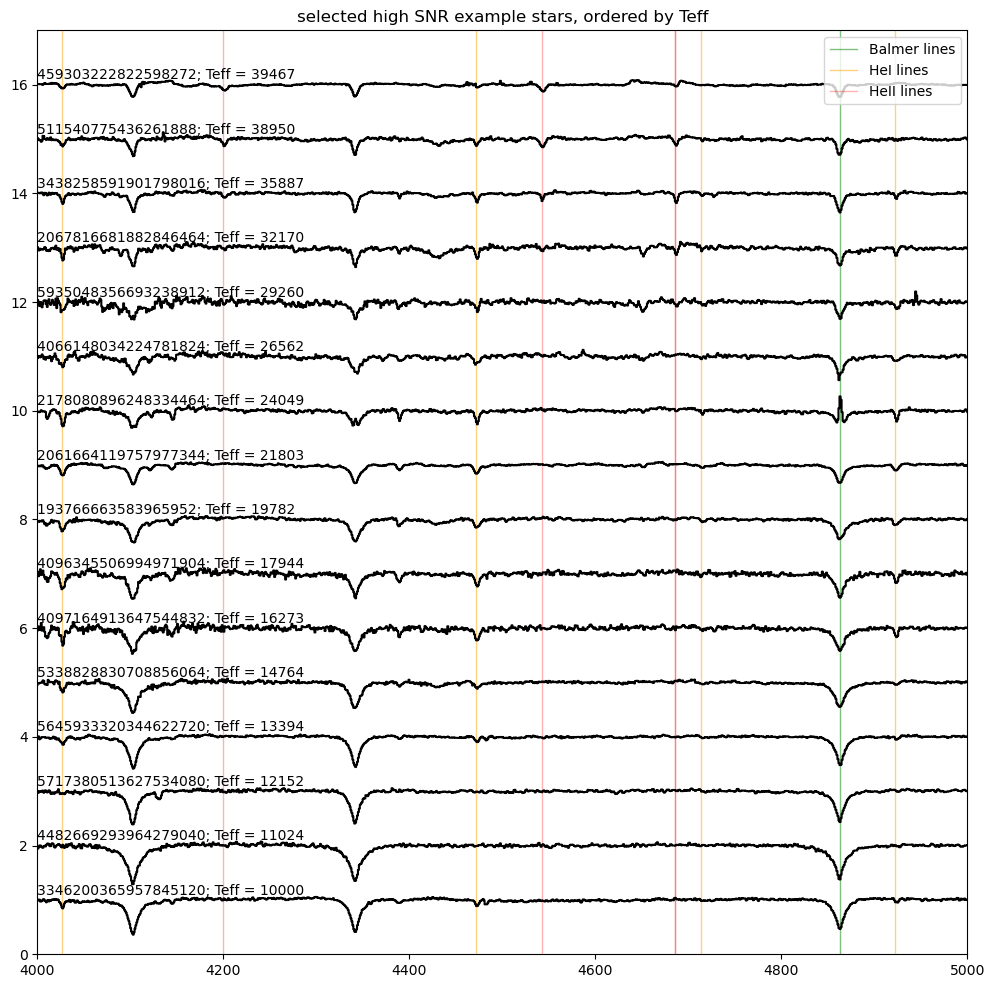

In [15]:
# make a sanity plot
tempposts = np.exp(np.linspace(np.log(np.min(spectra["Teff_fit"].to_numpy())), np.log(np.max(spectra["Teff_fit"].to_numpy())), 16))
f = plt.figure(figsize=(12, 12))
for t, T in enumerate(tempposts):
    # find closest high SNR spectrum
    highsnr = np.arange(len(spectra))[np.median(rest_ivars[:, :2000], axis=1) > 500.0]
    ii = np.argmin(np.abs(spectra["Teff_fit"].to_numpy()[highsnr] - T))
    ii = highsnr[ii]
    Teff = spectra["Teff_fit"].iloc[ii]
    print(t, T, ii, Teff)
    # plot it
    plt.step(10. ** loglam, rest_fluxes[ii] + t, c="k", where="mid")
    gid = spectra["GAIA_ID"].iloc[ii]
    label = f"{gid}; Teff = {Teff:5.0f}"
    plt.text(4000., 1.1 + t, label)
plt.ylim(0., len(tempposts) + 1.)
plt.xlim(4000, 5000)
#plt.xlim(H_ALPHA - 200, H_ALPHA + 200)

lines_balmer = [H_ALPHA, H_BETA]
lines_HE_I = [HE_I_6680, HE_I_4026, HE_I_4471, HE_I_4922, HE_I_4713]
lines_HE_II = [HE_II_4686, HE_II_4542, HE_II_4200]

for l, line in enumerate(lines_balmer):
    if l == 0:
        plt.axvline(line, label = "Balmer lines", lw=1, alpha=0.5, zorder=-10, color = "green")
    else:
        plt.axvline(line, lw=1, alpha=0.5, zorder=-10, color = "green")
        
for l, line in enumerate(lines_HE_I):
    if l == 0: 
        plt.axvline(line, label = "HeI lines", lw=1, alpha=0.5, zorder=-10, color = "orange")
    else:
        plt.axvline(line, lw=1, alpha=0.5, zorder=-10, color = "orange")
        
for l, line in enumerate(lines_HE_II):
    if l == 0: 
        plt.axvline(line, label = "HeII lines", lw=1, alpha=0.3, zorder=-10, color = "red")
    
    plt.axvline(line, lw=1, alpha=0.3, zorder=-10, color = "red")

plt.legend()    
plt.title("selected high SNR example stars, ordered by Teff")

In [23]:
def idkyet(spectra_df, Tcuts, rest_flxes, rest_ivrs, lines, log_lambdas,  K = 12, scale = 1, nu = 1, mod_list = [0,1]):

    model_dict = {}
    synths = np.zeros_like(rest_flxes) + np.nan
    spec_temps = spectra_df['Teff_fit'].to_numpy() 

    total_spectra_sum = 0
    
    #censoring
    log_lines = np.log10(lines)
    log_H_ALPHA, log_H_BETA = log_lines[0], log_lines[1]
    region_alpha = np.abs(log_lambdas - log_H_ALPHA)
    region_beta = np.abs(log_lambdas - log_H_BETA)
    censor_mask = np.ones_like(log_lambdas)
    censor_mask[(region_alpha < H_delta_loglam_line) | (region_beta < H_delta_loglam_line) ] = 0 #?

    for m in mod_list:
        for t in range(len(Tcuts) - 1):

            #get training and testing indices
            train_indx = ((spectra_df['NANA_HASH'].to_numpy()%2 == m) &
                          (spec_temps >= Tcuts[t]) &
                          (spectra_df['EWobs_Halpha'].to_numpy() > 0.0) &
                          (spectra_df['nana_Halpha_EW'].to_numpy() < 1.0))

            test_indx = ((spectra_df['NANA_HASH'].to_numpy()%2 != m) &
                         (spec_temps >= Tcuts[t]) &
                         (spec_temps < Tcuts[t + 1]))

            print(f"For temp {Tcuts[t]} and mod {m}: There are {train_indx.sum()} spectra in TRAIN and {test_indx.sum()} spectra in TEST")
            print(f"Model: temp {Tcuts[t]} and mod {m}")
            model = Robusta(rank=K, robust=True, robust_scale = scale, robust_nu = nu)
            start = time.perf_counter()
            model.fit(rest_flxes[train_indx], rest_ivrs[train_indx], max_iter=10000)
            end = time.perf_counter()
            print("total time:", (end - start)/60, "minutes")

            #synthesize 
            state, _ = model.infer(rest_flxes[test_indx], rest_ivrs[test_indx] * censor_mask[None, :])
            synths[test_indx] = model.synthesize(state)

            model_dict[(m, t)] = (model, train_indx, test_indx)
            print(synths[test_indx].shape)
            total_spectra_sum+=synths[test_indx].sum()
            print(m, t, np.sum(train_indx), np.sum(test_indx))

            
        print(np.sum(np.isfinite(synths)))
        print("Total synthesized spectra is", total_spectra_sum)

        #
        

    return synths, model_dict

In [24]:
synth_spectra, mod_dict = idkyet(spectra, temp_cuts, data, weights, all_lines, loglam)

For temp 10000.0 and mod 0: There are 11294 spectra in TRAIN and 8576 spectra in TEST
Model: temp 10000.0 and mod 0
Initializing state... done.
iter 011 | loss 14125881.3032
iter 021 | loss 14102153.8451
iter 031 | loss 14098270.7639
iter 041 | loss 14096401.7410
iter 051 | loss 14095304.6104
iter 061 | loss 14094672.8630
iter 071 | loss 14094324.4750
iter 081 | loss 14094138.4621
iter 091 | loss 14094041.0611
iter 101 | loss 14093989.1269
iter 111 | loss 14093960.2544
iter 121 | loss 14093942.6216
iter 131 | loss 14093929.8770
iter 141 | loss 14093919.1383
iter 151 | loss 14093910.1831
iter 161 | loss 14093902.6446
iter 171 | loss 14093896.3072
iter 181 | loss 14093890.6116
iter 191 | loss 14093885.5683
iter 201 | loss 14093881.2841
iter 211 | loss 14093877.4012
iter 221 | loss 14093872.9491
iter 231 | loss 14093869.2220
iter 241 | loss 14093866.4540
iter 251 | loss 14093864.1304
iter 261 | loss 14093862.1608
iter 271 | loss 14093860.4929
iter 281 | loss 14093859.1056
iter 291 | loss 

In [32]:
len(all_line_labels)

10

In [256]:
def compute_moments(spectra_df, synths, log_lambda, rest_flxes, rest_ivrs, lines, line_labels, half_widths, moment_labels, nana = "nana_"):

    synthesized = np.isfinite(synths).all(axis=1)
    print(synthesized.sum())
    flxs = rest_flxes[synthesized]
    ivrs = rest_ivrs[synthesized]
    synth = synths[synthesized]
    resid = flxs - synth

    print(flxs.shape, ivrs.shape, synth.shape, resid.shape)
    
    delta_log_lambda_pixel = get_delta_log_lam(log_lambda)
    lam = 10 ** log_lambda
    exponents = np.arange(5)

    for j, (line, wid, line_label) in enumerate(zip(lines, half_widths, line_labels)):
        logline = np.log10(line)
        integration_weight = delta_log_lambda_pixel * LN10 * lam * (np.abs(logline - log_lambda) < wid)
        diff = lam - line  # hogg's lam - lam0

        col_name = nana + line_label + "_"

        for k, (expo, stat) in enumerate(zip(exponents, moment_labels)):
            something = integration_weight * diff ** expo
            moment_vals = np.sum(resid * something[None, :], axis=1)
            moment_err_vals = np.sqrt(np.sum(something[None, :] ** 2 / ivrs, axis=1))

            spectra_df.loc[synthesized, col_name + stat] = moment_vals
            spectra_df.loc[synthesized, col_name + stat + "_err"] = moment_err_vals


    return spectra_df

In [261]:
def compute_moments_synth(spectra_df, synths, log_lambda, rest_flxes, rest_ivrs, lines, line_labels, half_widths, moment_labels, nana = "nana_"):

    synthesized = np.isfinite(synths).all(axis=1)
    print(synthesized.sum())
    flxs = rest_flxes[synthesized]
    ivrs = rest_ivrs[synthesized]
    synth = synths[synthesized]

    print(flxs.shape, ivrs.shape, synth.shape, resid.shape)
    
    delta_log_lambda_pixel = get_delta_log_lam(log_lambda)
    lam = 10 ** log_lambda
    exponents = np.arange(5)

    for j, (line, wid, line_label) in enumerate(zip(lines, half_widths, line_labels)):
        logline = np.log10(line)
        integration_weight = delta_log_lambda_pixel * LN10 * lam * (np.abs(logline - log_lambda) < wid)
        diff = lam - line  # hogg's lam - lam0

        col_name = nana + line_label + "_"

        for k, (expo, stat) in enumerate(zip(exponents, moment_labels)):
            something = integration_weight * diff ** expo
            moment_vals = np.sum(synth * something[None, :], axis=1)
            moment_err_vals = np.sqrt(np.sum(something[None, :] ** 2 / ivrs, axis=1))          

            spectra_df.loc[synthesized, col_name + stat +"_synth"] = moment_vals
            spectra_df.loc[synthesized, col_name + stat + "_synth_err"] = moment_err_vals


    return spectra_df

In [299]:
spectra = compute_moments_synth(spectra, synth_spectra, loglam, data, weights, all_lines, all_line_labels, half_wids, moment_names)

24713
(24713, 4648) (24713, 4648) (24713, 4648) (24713, 4648)


In [300]:
spectra = compute_moments(spectra, synth_spectra, loglam, data, weights, all_lines, all_line_labels, half_wids, moment_names)

24713
(24713, 4648) (24713, 4648) (24713, 4648) (24713, 4648)


/var/folders/_f/c3__1v4j349bfc51yh6jhk_w0000gp/T/ipykernel_984/1819990710.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  spectra_df.loc[synthesized, col_name + stat] = moment_vals
/var/folders/_f/c3__1v4j349bfc51yh6jhk_w0000gp/T/ipykernel_984/1819990710.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  spectra_df.loc[synthesized, col_name + stat + "_err"] = moment_err_vals
/var/folders/_f/c3__1v4j349bfc51yh6jhk_w0000gp/T/ipykernel_984/1819990710.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually

0 10000.00000000001 13696 10000.0
1 11023.104765790147 20764 11023.679343987918
2 12150.883867758515 11993 12151.6784909076
3 13394.04658712514 22839 13394.17958049255
4 14764.397876775427 15653 14764.089910014782
5 16274.9504599505 18322 16272.624400393652
6 17940.048397807845 10389 17944.14397135685
7 19775.50329923814 14787 19781.862080737672
8 21798.744466373053 11568 21802.971557655124
9 24028.98440155182 2512 24049.3217104071
10 26487.40124738423 20369 26562.211972423305
11 29197.339892343676 15793 29260.07789150486
12 32184.53365156881 6397 32169.93647889888
13 35477.34862793412 14719 35887.06576470069
14 39107.05307381782 12345 38950.47128094957
15 43108.1143114009 12754 39466.9904606415


Text(0.5, 1.0, 'selected high SNR example stars, ordered by Teff')

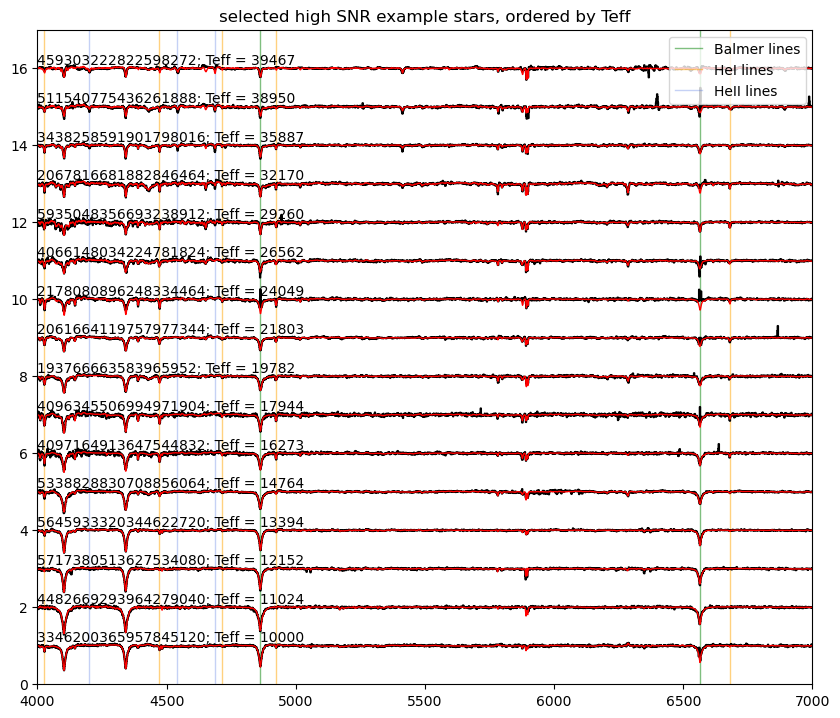

In [301]:
# make another sanity plot
tempposts = np.exp(np.linspace(np.log(np.min(spectra["Teff_fit"].to_numpy())), np.log(np.max(spectra["Teff_fit"].to_numpy())), 16))
f = plt.figure(figsize=(10, 8.5))
for t, T in enumerate(tempposts):
    # find closest high SNR spectrum
    highsnr = np.arange(len(spectra))[np.median(rest_ivars[:, :2000], axis=1) > 500.0]
    ii = np.argmin(np.abs(spectra["Teff_fit"].to_numpy()[highsnr] - T))
    ii = highsnr[ii]
    Teff = spectra["Teff_fit"].iloc[ii]
    print(t, T, ii, Teff)
    # plot it
    plt.step(10. ** loglam, data[ii] + t, c="k", where="mid")
    plt.plot(10. ** loglam, synth_spectra[ii] + t,"r-", lw = 1)
    gid = spectra["GAIA_ID"].iloc[ii]
    label = f"{gid}; Teff = {Teff:5.0f}"
    plt.text(4000., 1.1 + t, label)
plt.ylim(0., len(tempposts) + 1.)
plt.xlim(4000, 7000)
#plt.xlim(H_ALPHA - 200, H_ALPHA + 200)

lines_balmer = [H_ALPHA, H_BETA]
lines_HE_I = [HE_I_6680, HE_I_4026, HE_I_4471, HE_I_4922, HE_I_4713]
lines_HE_II = [HE_II_4686, HE_II_4542, HE_II_4200]

for l, line in enumerate(lines_balmer):
    if l == 0:
        plt.axvline(line, label = "Balmer lines", lw=1, alpha=0.5, zorder=-10, color = "green")
    else:
        plt.axvline(line, lw=1, alpha=0.5, zorder=-10, color = "green")
        
for l, line in enumerate(lines_HE_I):
    if l == 0: 
        plt.axvline(line, label = "HeI lines", lw=1, alpha=0.5, zorder=-10, color = "orange")
    else:
        plt.axvline(line, lw=1, alpha=0.5, zorder=-10, color = "orange")
        
for l, line in enumerate(lines_HE_II):
    if l == 0: 
        plt.axvline(line, label = "HeII lines", lw=1, alpha=0.3, zorder=-10, color = "royalblue")
    else:
        plt.axvline(line, lw=1, alpha=0.3, zorder=-10, color = "royalblue")

plt.legend()    
plt.title("selected high SNR example stars, ordered by Teff")

In [302]:
m1 = spectra["nana_Halpha_M1"].to_numpy()
m1_errs= spectra["nana_Halpha_M1_err"].to_numpy()

ew = spectra["nana_Halpha_EW"].to_numpy()
ew_errs = spectra["nana_Halpha_EW_err"].to_numpy()

m2 = spectra["nana_Halpha_M2"].to_numpy()
m2_errs = spectra["nana_Halpha_M2_err"].to_numpy()

m3 = spectra["nana_Halpha_M3"].to_numpy()
m3_errs = spectra["nana_Halpha_M3_err"].to_numpy()

m4 = spectra["nana_Halpha_M3"].to_numpy()
m4_errs = spectra["nana_Halpha_M3_err"].to_numpy()

In [303]:
#All for Halpha
centroid = m1 / ew                     
linewidth = np.sqrt(m2 / ew)                 
skew = (m3 / ew) / (m2 / ew) ** 1.5
kurtosis = (m4 / ew) / (m2 / ew) ** 2    

/var/folders/_f/c3__1v4j349bfc51yh6jhk_w0000gp/T/ipykernel_984/2617167749.py:3: RuntimeWarning: invalid value encountered in sqrt
  linewidth = np.sqrt(m2 / ew)
/var/folders/_f/c3__1v4j349bfc51yh6jhk_w0000gp/T/ipykernel_984/2617167749.py:4: RuntimeWarning: invalid value encountered in power
  skew = (m3 / ew) / (m2 / ew) ** 1.5


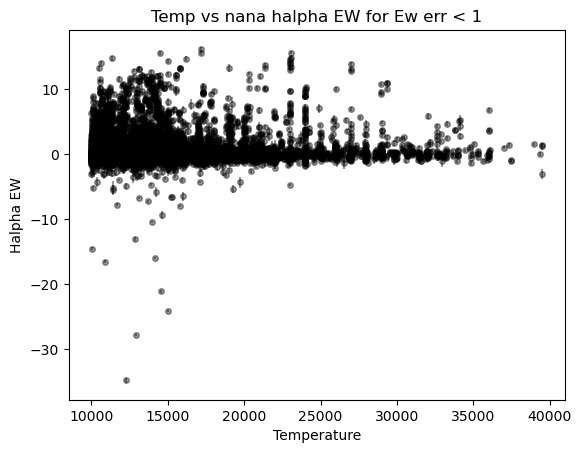

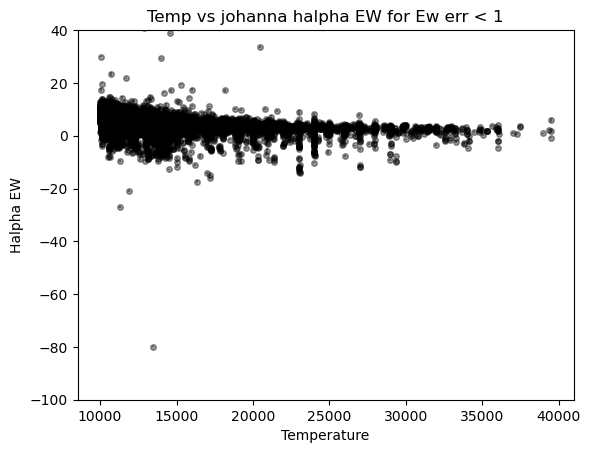

In [304]:
err_lim = ew_errs < 1.0
temps = spectra["Teff_fit"].to_numpy()

plt.errorbar(temps[err_lim], ew[err_lim], yerr=ew_errs[err_lim], fmt = "o", alpha = 0.4, markersize = 4, color = "black")
plt.xlabel("Temperature")
plt.ylabel("Halpha EW")
plt.title("Temp vs nana halpha EW for Ew err < 1")
plt.show()

plt.errorbar(temps[err_lim], johanna_ew[err_lim], yerr=ew_errs[err_lim], fmt = "o", alpha = 0.4, markersize = 4, color = "black")
plt.xlabel("Temperature")
plt.ylabel("Halpha EW")
plt.ylim(-100, 40)
plt.title("Temp vs johanna halpha EW for Ew err < 1")
plt.show()

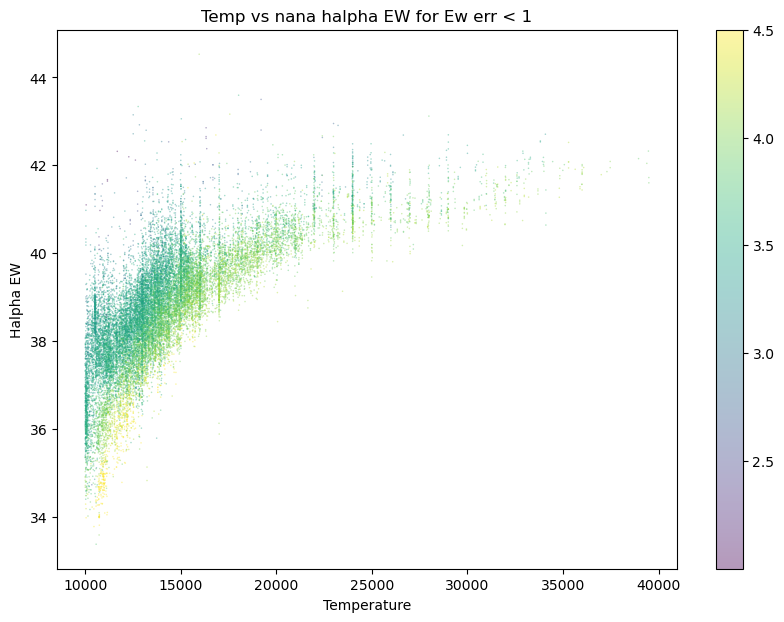

In [313]:
f = plt.figure(figsize = (10,7))
err_lim = ew_errs < 1.0
temps = spectra["Teff_fit"].to_numpy()
#log_g = spectra["logg_fit"].to_numpy()
ew_synth = spectra["nana_Halpha_EW_synth"].to_numpy() 
mask = spectra["nana_Halpha_EW_synth_err"].to_numpy() < 1
plt.scatter(temps[mask], ew_synth[mask], c = spectra["logg_fit"].to_numpy()[mask], marker='.',lw=0, alpha = 0.4, s = 5)
plt.xlabel("Temperature")
plt.ylabel("Halpha EW")
plt.title("Temp vs nana halpha EW for Ew err < 1")
plt.colorbar()
#plt.ylim(-1,5)
#plt.xlim(10000,20000)
plt.show()

#plt.scatter(temps[err_lim], johanna_ew[err_lim], yerr=ew_errs[err_lim], fmt = "o", alpha = 0.4, markersize = 4, color = "black")
#plt.xlabel("Temperature")
#plt.ylabel("Halpha EW")
#plt.ylim(-100, 40)
#plt.title("Temp vs johanna halpha EW for Ew err < 1")
#plt.show()


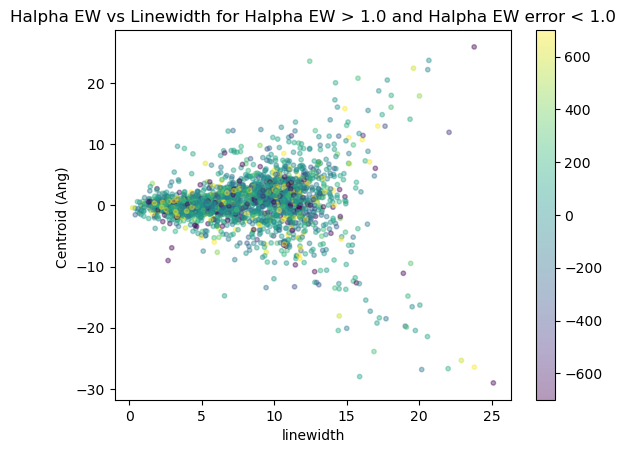

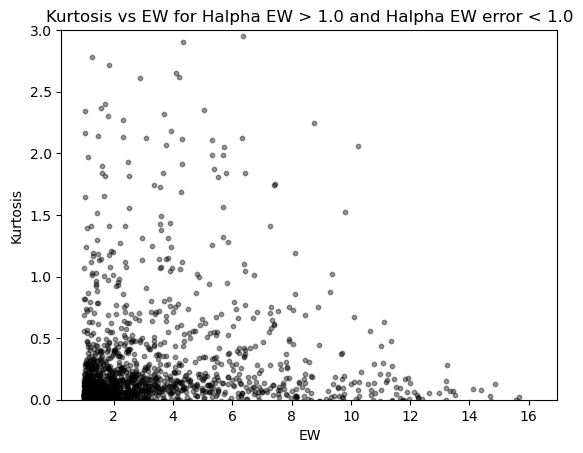

In [306]:
#For the lines with Halpha EW > 1.0 and Halpha EW error < 1.0, we should plot Halpha line_offset vs line_width and kurtosis vs EW
vsii = spectra["velocity_SiII4128"].to_numpy()
    
select_ew = (ew > 1.0) & (ew_errs < 1.0)
plt.title("Halpha EW vs Linewidth for Halpha EW > 1.0 and Halpha EW error < 1.0")
plt.xlabel("linewidth")
plt.ylabel("Centroid (Ang) ")
plt.scatter(linewidth[select_ew], centroid[select_ew], alpha = 0.4, c = vsii[select_ew] , s = 10)
plt.colorbar()
plt.show()

plt.title("Kurtosis vs EW for Halpha EW > 1.0 and Halpha EW error < 1.0")
plt.ylabel("Kurtosis")
plt.xlabel("EW")
plt.ylim(0., 3)
plt.scatter(ew[select_ew], kurtosis[select_ew], alpha = 0.4, s = 10, color = "k")

2942


<ErrorbarContainer object of 3 artists>

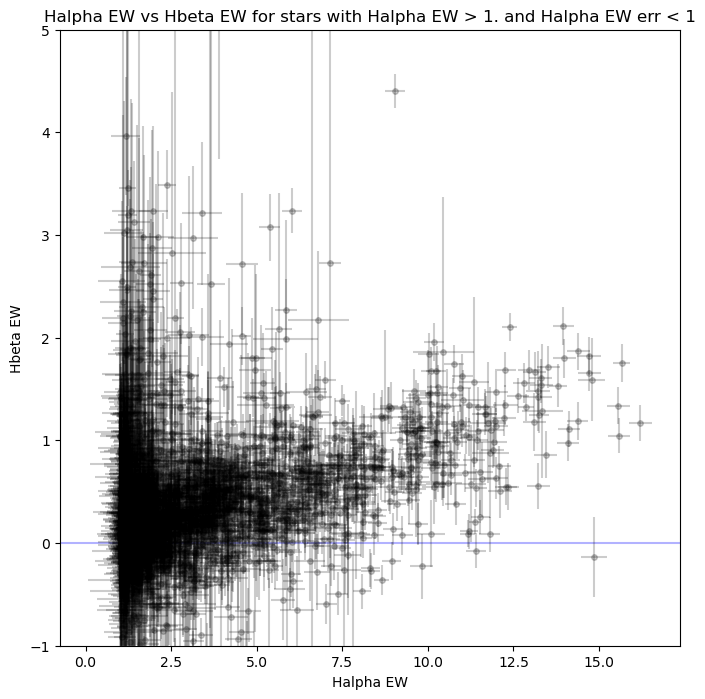

In [227]:
#Halpha EW vs Hbeta EW for stars with Halpha EW > 1. and Halpha EW err > 1. With error bars.

#try out the Hgamma and Hdelta, we don't expect emission

ew_beta = spectra["nana_Hbeta_EW"].to_numpy()
ew_beta_errs = spectra["nana_Hbeta_EW_err"].to_numpy()

mask = (ew > 1.0) & (ew_errs < 1.0)
f = plt.figure(figsize=(8, 8))
plt.xlabel("Halpha EW")
plt.ylabel("Hbeta EW")
plt.title("Halpha EW vs Hbeta EW for stars with Halpha EW > 1. and Halpha EW err < 1")
plt.axhline(0, alpha = 0.3, color = "blue")
plt.ylim(-1, 5)
print(mask.sum())
plt.errorbar(ew[mask], ew_beta[mask], xerr = ew_errs[mask], yerr = ew_beta_errs[mask], alpha = 0.2, fmt = "o", markersize = 4, color = "black")

In [136]:
print(data.shape, synth_spectra.shape)

(24713, 4648) (24713, 4648)


(1163,)
(24713,)
[14397 13034  2832 16552 12626  7497  6586 12634 20107 13977 12963 23068]


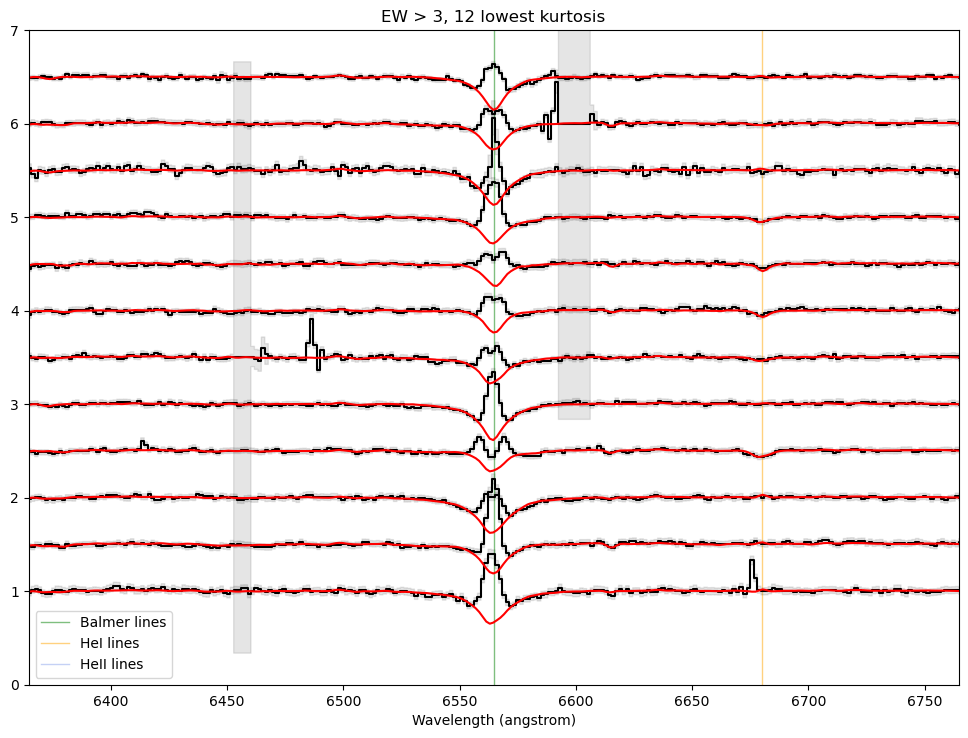

In [241]:
#Then we should plot the spectra of the 12 stars with EW > 3 (say) and lowest kurtosis.

valid_indices = np.where((ew > 3) & (ew_errs < 1))[0]
print(valid_indices.shape)

print(kurtosis.shape)
sorted_order = np.argsort(kurtosis[valid_indices])
indices = valid_indices[sorted_order[:12]]

print(indices)

f = plt.figure(figsize=(12, 8.5))
lam = 10 ** loglam

offset = 0.5
nplot = 12
for i in range(nplot):
    f.gca().fill_between(lam, data[indices[i]] - 1. / np.sqrt(weights[indices[i]]) + i * offset,
                         data[indices[i]] + 1. / np.sqrt(weights[indices[i]]) + i * offset,
                         color="k", step = "mid", alpha=0.1)
    f.gca().step(lam, data[indices[i]] + i * offset, color="k", where = "mid")
    f.gca().plot(lam, synth_spectra[indices[i]] +  i* offset, color="r")

for l, line in enumerate(lines_balmer):
    if l == 0:
        plt.axvline(line, label = "Balmer lines", lw=1, alpha=0.5, zorder=-10, color = "green")
    else:
        plt.axvline(line, lw=1, alpha=0.5, zorder=-10, color = "green")
        
for l, line in enumerate(lines_HE_I):
    if l == 0: 
        plt.axvline(line, label = "HeI lines", lw=1, alpha=0.5, zorder=-10, color = "orange")
    else:
        plt.axvline(line, lw=1, alpha=0.5, zorder=-10, color = "orange")
        
for l, line in enumerate(lines_HE_II):
    if l == 0: 
        plt.axvline(line, label = "HeII lines", lw=1, alpha=0.3, zorder=-10, color = "royalblue")
    else:
        plt.axvline(line, lw=1, alpha=0.3, zorder=-10, color = "royalblue")

plt.legend()    
plt.xlim(H_ALPHA-200, H_ALPHA+200)
#plt.xlim(H_BETA-500, H_BETA+500)
plt.ylim(0., nplot * offset + 1)
plt.xlabel("Wavelength (angstrom)")
plt.title("EW > 3, 12 lowest kurtosis")
plt.show()
plt.close()


In [ ]:
def plot_synthesized(synthB, rest_fluxes, Binx, log_lambda, lines, K = 12):
    
    f = plt.figure(figsize=(15, 15))
    wave = 10 ** log_lambda
    
    offset = 0.5
    for i in range(12):
        f.gca().plot(wave, rest_fluxes[Binx[i]] + i * offset, color="k")
        f.gca().plot(wave, synthB[i] + i * offset, color="r")

    for line in lines: 
        plt.axvline(line, lw=1, alpha=0.5, color="b")
    plt.xlim(4200, 7000)
    plt.xlabel("Wavelength (angstrom)")
    plt.show()
    plt.close()


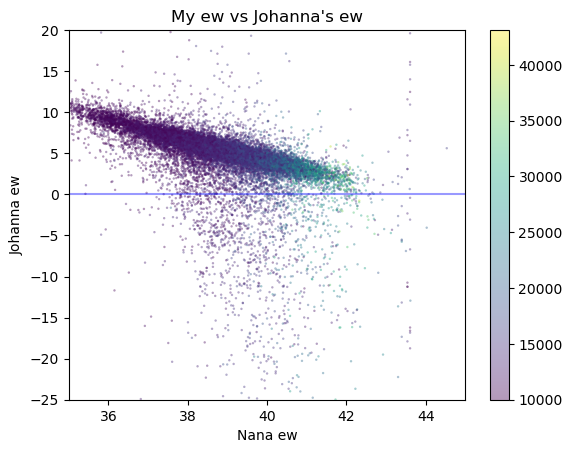

In [289]:
johanna_ew = spectra["EWobs_Halpha"].to_numpy()
nana_ew = spectra["nana_Halpha_EW_synth"].to_numpy()
plt.title("My ew vs Johanna's ew")
plt.xlabel("Nana ew")
plt.ylabel("Johanna ew")
plt.scatter(nana_ew, johanna_ew, alpha = 0.4,s = 3, lw=0, c = temps)
plt.axvline(0, color = "blue", alpha = 0.4)
plt.axhline(0, color = "blue", alpha = 0.4)
# plt.xlim(-5,20)
# plt.ylim(-15,10)
plt.xlim(35,45)
plt.ylim(-25,20)
plt.colorbar()
plt.show()

In [378]:
spectra["nana_bof"] = 1.0
spectra.columns.to_list()

/var/folders/_f/c3__1v4j349bfc51yh6jhk_w0000gp/T/ipykernel_984/2420486297.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  spectra["nana_bof"] = 1.0


['FIELD',
 'MJD',
 'OBS',
 'MJD_FINAL',
 'MJD_LIST',
 'TAI_LIST',
 'RUN2D',
 'RUN1D',
 'DESIGNS',
 'CONFIGS',
 'NEXP',
 'EXPTIME',
 'TARGET_INDEX',
 'FIBERID_LIST',
 'SPEC_FILE',
 'PROGRAMNAME',
 'SURVEY',
 'CADENCE',
 'FIRSTCARTON',
 'CARTON_TO_TARGET_PK',
 'OBJTYPE',
 'TOO',
 'TOO_ID',
 'CATALOGID',
 'CATALOGID_V0',
 'CATALOGID_V0P5',
 'CATALOGID_V1',
 'SDSS_ID',
 'SPECOBJID',
 'OPTICAL_PROV',
 'GAIA_G_MAG',
 'GRI_GAIA_TRANSFORM',
 'BP_MAG',
 'RP_MAG',
 'GAIA_ID',
 'WISE_MAG_1',
 'WISE_MAG_2',
 'WISE_MAG_3',
 'WISE_MAG_4',
 'TWOMASS_MAG_1',
 'TWOMASS_MAG_2',
 'TWOMASS_MAG_3',
 'GUVCAT_MAG_1',
 'GUVCAT_MAG_2',
 'EBV',
 'EBV_TYPE',
 'FIBER_RA',
 'FIBER_DEC',
 'PLUG_RA',
 'PLUG_DEC',
 'RACAT',
 'DECCAT',
 'COORD_EPOCH',
 'PMRA',
 'PMDEC',
 'PARALLAX',
 'RA_LIST',
 'DEC_LIST',
 'DELTA_RA_LIST',
 'DELTA_DEC_LIST',
 'FIBER_OFFSET',
 'XFOCAL',
 'YFOCAL',
 'ZOFFSET',
 'LAMBDA_EFF',
 'BLUEFIBER',
 'HEALPIX',
 'HEALPIXGRP',
 'HEALPIX_PATH',
 'FIELDQUALITY',
 'EXP_DISP_MED',
 'FIELDSN2',
 'FIEL

In [204]:
resid = data - synth_spectra
chis2 = np.percentile(resid ** 2 * weights, [50, 75, 90], axis = 1)
print(chis2.shape)

(3, 24713)


In [379]:
spectra["nana_bof"] = chis2[2]

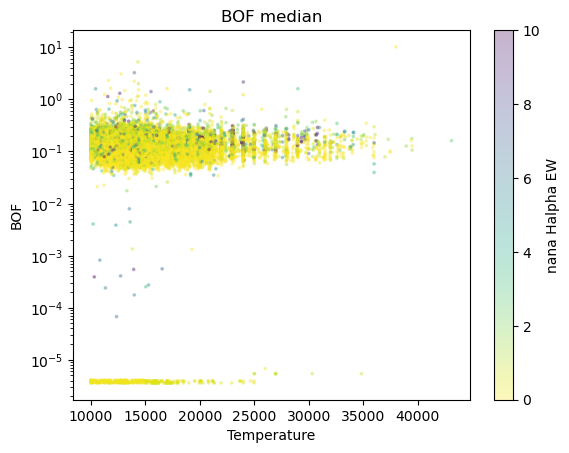

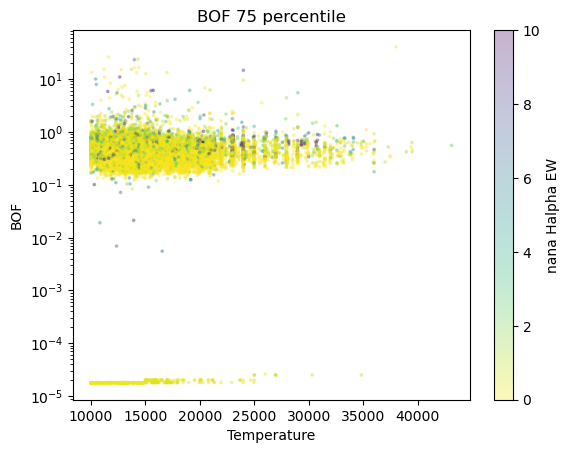

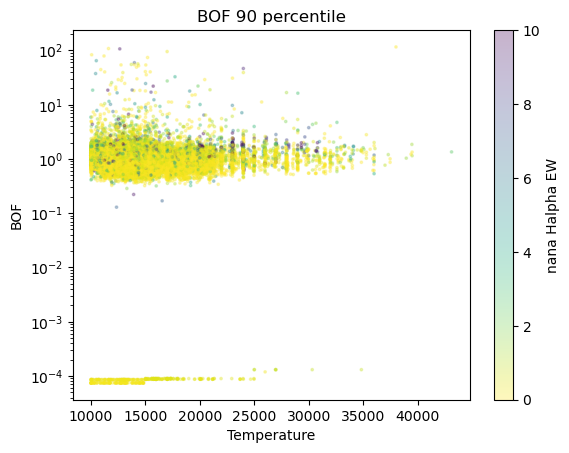

In [327]:
plt.scatter(temps, chis2[0], alpha = 0.3, c = ew, s = 3, cmap='viridis_r', vmin = 0, vmax = 10)
plt.title("BOF median")
plt.xlabel("Temperature")
plt.ylabel("BOF")
plt.colorbar().set_label("nana Halpha EW")
plt.semilogy()
plt.axhline(0, alpha = 0.4)
plt.show()

plt.scatter(temps, chis2[1], alpha = 0.3, c = ew, s = 3, cmap='viridis_r', vmin = 0, vmax = 10)
plt.title("BOF 75 percentile")
plt.xlabel("Temperature")
plt.ylabel("BOF")
plt.colorbar().set_label("nana Halpha EW")
plt.semilogy()
plt.axhline(0, alpha = 0.4)
plt.show()

plt.scatter(temps, chis2[2], alpha = 0.3, c = ew, s = 3, cmap='viridis_r', vmin = 0, vmax = 10)
plt.title("BOF 90 percentile")
plt.xlabel("Temperature")
plt.ylabel("BOF")
plt.colorbar().set_label("nana Halpha EW")
plt.axhline(0, alpha = 0.4)
plt.semilogy()
plt.show()



[]

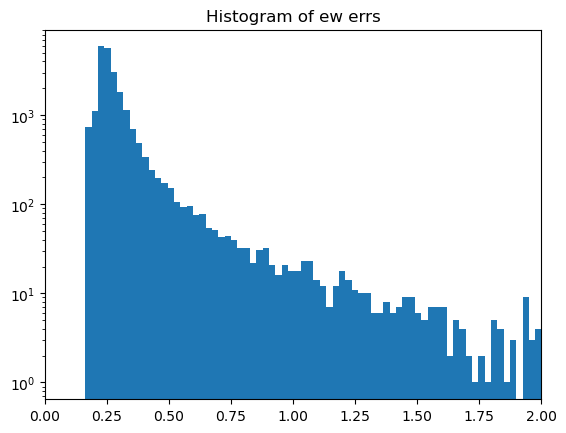

In [224]:
#even more stats and plots!!
plt.hist(ew_errs, bins = 1000)
plt.title("Histogram of ew errs")
plt.xlim(0,2)
plt.semilogy()

In [ ]:
#create pretty spectra plot
#data shoudl be black, model should be red, data should also be a mid-step while the psectra should be continuous
#balmer lines should get a color, non balmer get another color

#the input for this plotting code (data[i[, synth[i[, spectra_df), in inputs initiualize to synth = N

#n the Halpha, Hbeta, and He (add the ew and stats for each subplot)

In [325]:
print(ew)

[ 0.42680106 -0.25371111  1.33332146 ... -0.66178099  0.46656283
 -0.1715962 ]


In [ ]:
#plto five random spectra from the categories

there are this many: 824


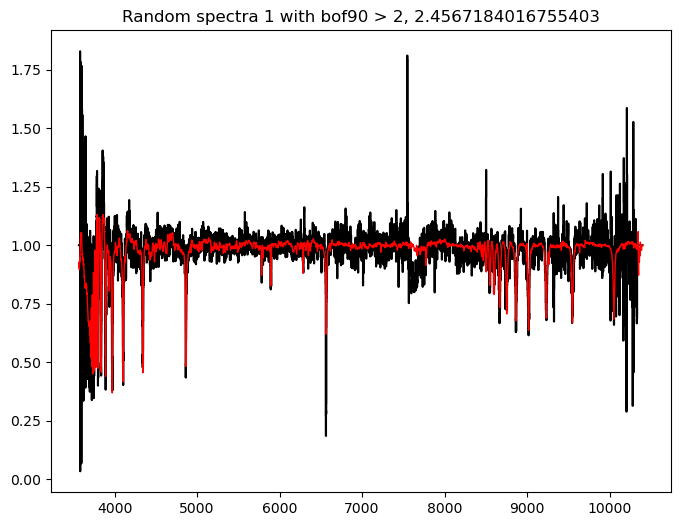

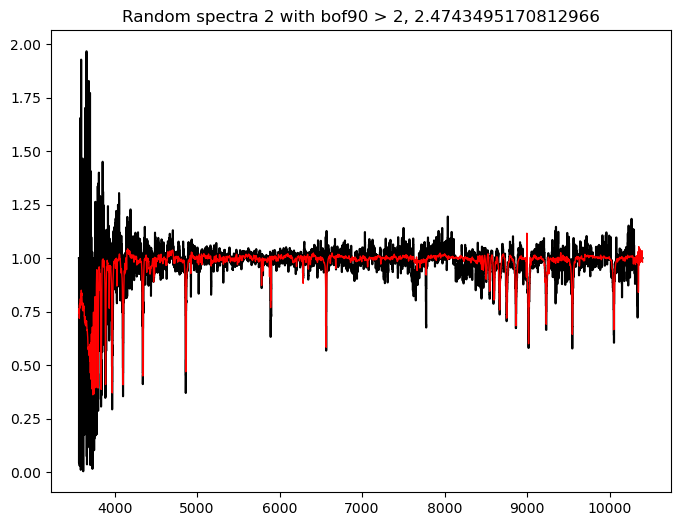

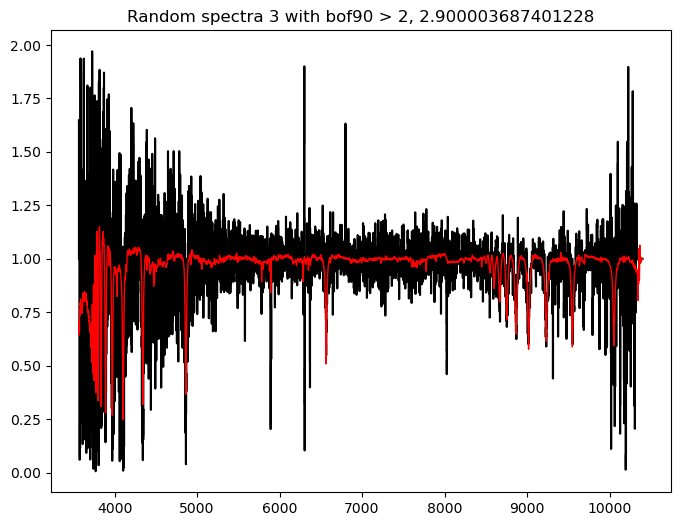

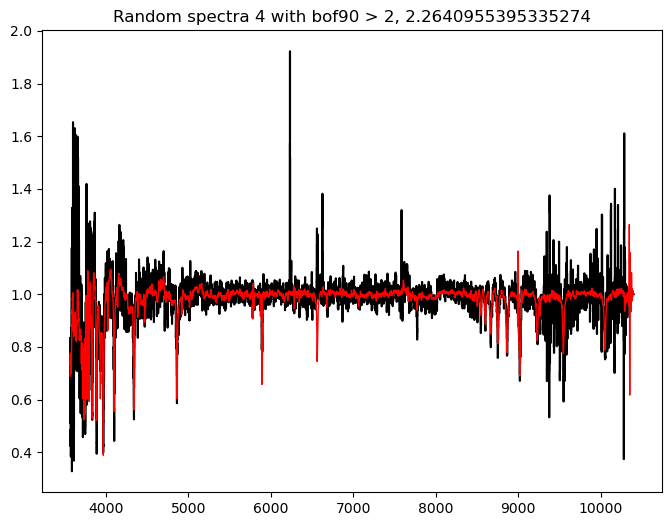

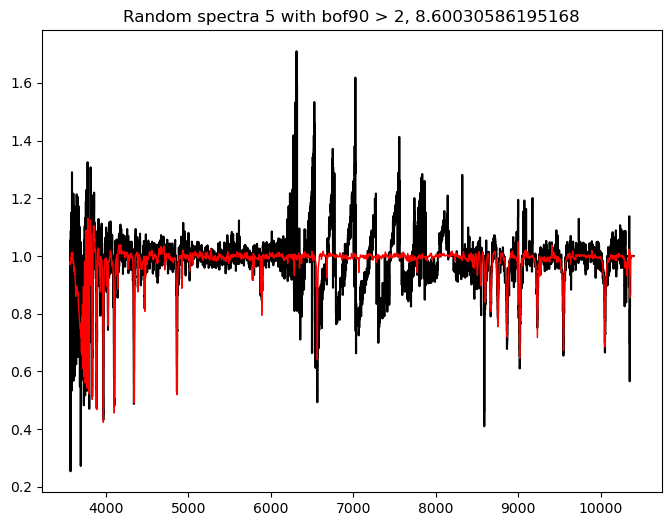

In [370]:
#plot 5 random wiht bof90 > 50
mask = (chis2[2] > 2)
indices = np.where(mask)
indices = np.array(indices[0])
print("there are this many:", len(indices))
rnd_indx = np.random.choice(indices, size = 5, replace = False)

for i, r_indx in enumerate(rnd_indx):
    f = plt.figure(figsize = (8,6))
    plt.step(10. ** loglam, data[r_indx], c="k", where="mid")
    plt.plot(10. ** loglam, synth_spectra[r_indx],"r-", lw = 1)
    plt.title(f"Random spectra {i+1} with bof90 > 2, {chis2[2][r_indx]}")
    plt.show()

Text(0.5, 1.0, 'BOF 90 Histogram')

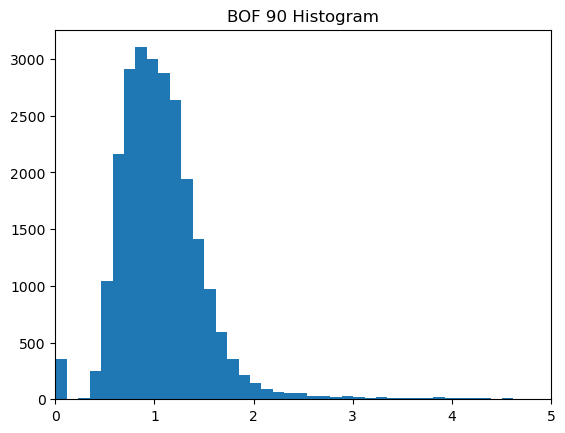

In [374]:
plt.hist(chis2[2], bins = 1000)
plt.xlim(0, 5)
plt.title("BOF 90 Histogram")
##CUT AT BOF 90 > 2!!!!!!

In [375]:
len(spectra["nana_Halpha_EW"].to_numpy())

24713

24713

In [380]:
iteration = 3

In [ ]:
for it in range(iteration):
    
    nana = "nana_"
    count = 0
    for l, line in enumerate(all_line_labels):
        col_name = nana + line + "_"
        print(col_name)
        for s, stat in enumerate(moment_names):
            ##add column here
                #print(col_name + stat)
                spectra[col_name + stat] = 0.
                count+=1
                spectra[col_name + stat + "_err"] = np.inf
                count+=1
    

In [ ]:
def iterate_and_get_file(spectra_df, iters = 3):
    